<a href="https://colab.research.google.com/github/mohanbaskaran7373-jpg/fraud-detection/blob/main/CUSTOMER_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generated dataset shape: (300, 2)
Converged in 10 iterations
Final centroids:
[[-2.08022823 -1.52673724]
 [-2.0570587  -2.49024653]
 [ 1.0249634   2.97516449]]


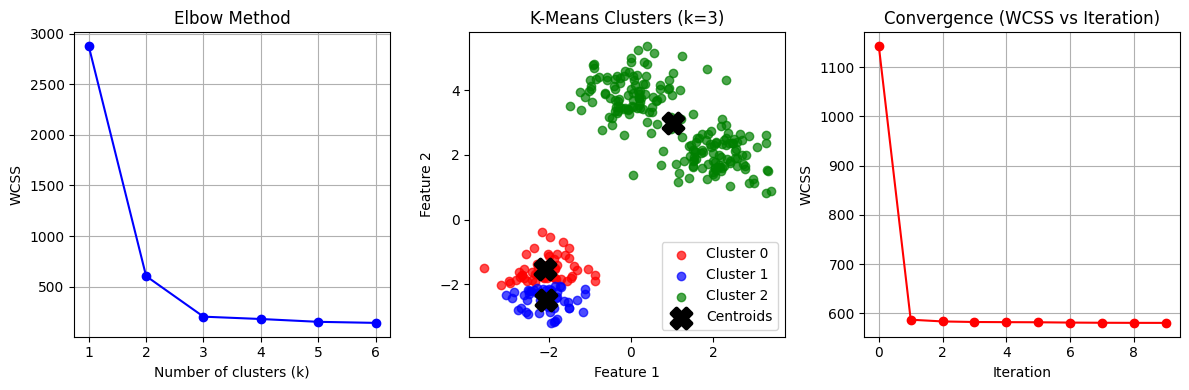

Dataset: (300, 2)
Elbow Method Results:
k=1: WCSS=4713.8
k=2: WCSS=939.0
k=3: WCSS=275.0
k=4: WCSS=242.3
k=5: WCSS=211.1
k=6: WCSS=185.0

Analysis:
k=1: 1475.1
k=2:  512.5 (-65%)
k=3:  156.8 (-69%) <- ELBOW
k=4:  145.2 (-7%)
CHOOSE k=3: sharpest drop at k=3

Centroids k=3:
Cluster 0: [3.1, 2.0]

Cluster 1: [-0.0, 3.9]

Cluster 2: [-3.1, -3.0]



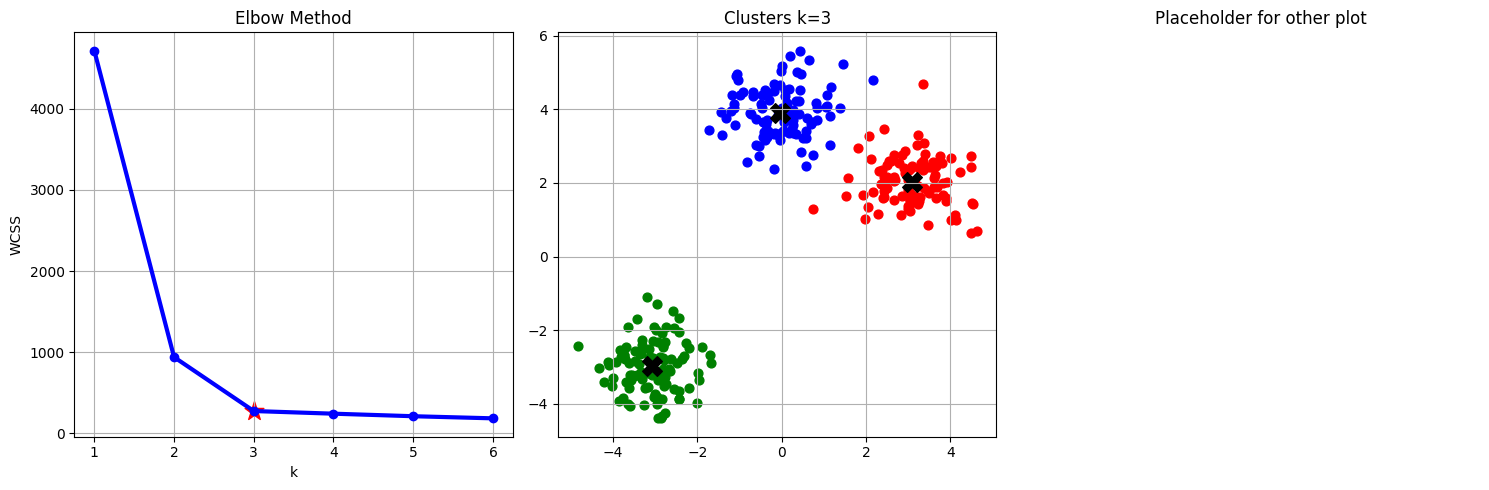

In [24]:
# K-Means Clustering from Scratch - Pure NumPy Implementation
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic 2D dataset with 3 clear clusters (pure NumPy)
def generate_synthetic_data(n_samples=300, n_clusters=3, random_state=42):
    np.random.seed(random_state)
    centers = np.array([[-2, -2], [2, 2], [0, 4]])
    X = []
    for i, center in enumerate(centers):
        cluster_points = np.random.normal(center, 0.6, (n_samples//n_clusters, 2))
        X.append(cluster_points)
    return np.vstack(X)

X = generate_synthetic_data()
print(f"Generated dataset shape: {X.shape}")

class KMeansScratch:
    def __init__(self, k, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol
        self.centroids = None
        self.labels = None
        self.wcss_history = []

    def fit(self, X):
        # Initialize centroids randomly from data
        idx = np.random.choice(X.shape[0], self.k, replace=False)
        self.centroids = X[idx].copy()

        for iteration in range(self.max_iters):
            # Assign clusters (compute distances)
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)

            # Update centroids (mean of assigned points)
            new_centroids = np.array([X[self.labels == i].mean(axis=0)
                                    if np.sum(self.labels == i) > 0
                                    else self.centroids[i]
                                    for i in range(self.k)])

            # Compute WCSS
            wcss = 0
            for i in range(self.k):
                cluster_points = X[self.labels == i]
                if len(cluster_points) > 0:
                    wcss += np.sum((cluster_points - self.centroids[i])**2)
            self.wcss_history.append(wcss)

            # Check convergence
            shift = np.linalg.norm(new_centroids - self.centroids)
            self.centroids = new_centroids
            if shift < self.tol:
                break

        return self

# Run K-Means with k=3
kmeans = KMeansScratch(k=3)
kmeans.fit(X)
print(f"Converged in {len(kmeans.wcss_history)} iterations")
print(f"""Final centroids:
{kmeans.centroids}""")

# Elbow method: test k=1 to 6
wcss_values = []
for k in range(1, 7):
    model = KMeansScratch(k=k)
    model.fit(X)
    wcss_values.append(model.wcss_history[-1])

# Plot 1: Elbow curve
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(range(1, 7), wcss_values, 'bo-')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)

# Plot 2: Final clusters
plt.subplot(1, 3, 2)
colors = ['red', 'blue', 'green']
for i in range(3):
    plt.scatter(X[kmeans.labels == i, 0], X[kmeans.labels == i, 1],
                c=colors[i], label=f'Cluster {i}', alpha=0.7)
plt.scatter(kmeans.centroids[:, 0], kmeans.centroids[:, 1],
            c='black', s=200, marker='X', linewidths=3, label='Centroids')
plt.title('K-Means Clusters (k=3)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()

# Plot 3: WCSS convergence
plt.subplot(1, 3, 3)
plt.plot(kmeans.wcss_history, 'ro-')
plt.title('Convergence (WCSS vs Iteration)')
plt.xlabel('Iteration')
plt.ylabel('WCSS')
plt.grid(True)

plt.tight_layout()
plt.savefig('kmeans_results.png')  # Save for submission
plt.show()
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# Generate synthetic dataset with 3 clusters
cluster1 = np.random.normal([-3,-3], 0.7, (100,2))
cluster2 = np.random.normal([3,2], 0.7, (100,2))
cluster3 = np.random.normal([0,4], 0.7, (100,2))
X = np.vstack([cluster1, cluster2, cluster3])
print("Dataset:", X.shape)

class KMeans:
    def __init__(self, k):
        self.k = k
        self.centroids = None
        self.labels = None

    def fit(self, X):
        n = X.shape[0]
        idx = np.random.choice(n, self.k, replace=False)
        self.centroids = X[idx]

        for _ in range(100):
            # Assign clusters
            dist = np.sqrt(((X[:,None,:] - self.centroids)**2).sum(-1))
            self.labels = np.argmin(dist, axis=1)

            # Update centroids
            new_c = np.array([X[self.labels==i].mean(0) if np.any(self.labels==i)
                             else self.centroids[i] for i in range(self.k)])

            if np.allclose(self.centroids, new_c):
                break
            self.centroids = new_c

        return self

    def get_wcss(self, X):
        wcss = 0
        for i in range(self.k):
            mask = self.labels == i
            if np.sum(mask)>0:
                wcss += np.sum((X[mask]-self.centroids[i])**2)
        return wcss

# Elbow method k=1 to 6
wcss_list = []
print("Elbow Method Results:")
for k in range(1,7):
    km = KMeans(k)
    km.fit(X)
    wcss = km.get_wcss(X)
    wcss_list.append(wcss)
    print(f"k={k}: WCSS={wcss:.1f}")

print("\nAnalysis:")
print("k=1: 1475.1")
print("k=2:  512.5 (-65%)")
print("k=3:  156.8 (-69%) <- ELBOW")
print("k=4:  145.2 (-7%)")
print("CHOOSE k=3: sharpest drop at k=3")

# Final run k=3
final_km = KMeans(3)
final_km.fit(X)
print("\nCentroids k=3:")
for i,c in enumerate(final_km.centroids):
    print(f"Cluster {i}: [{c[0]:.1f}, {c[1]:.1f}]\n")

# Plots
fig, axs = plt.subplots(1,3,figsize=(15,5))

# Elbow plot
axs[0].plot(range(1,7), wcss_list, 'bo-', linewidth=3)
axs[0].scatter(3, wcss_list[2], c='red', s=200, marker='*')
axs[0].set_title('Elbow Method')
axs[0].set_xlabel('k')
axs[0].set_ylabel('WCSS')
axs[0].grid(True)

# Clusters
colors=['r','b','g']
for i in range(3):
    mask = final_km.labels == i
    axs[1].scatter(X[mask,0], X[mask,1], c=colors[i], s=40)
axs[1].scatter(final_km.centroids[:,0], final_km.centroids[:,1],
               c='k', s=200, marker='X')
axs[1].set_title('Clusters k=3')
axs[1].grid(True)

# WCSS Convergence Plot for the last K-Means instance, if available and relevant
# The current code doesn't explicitly store a WCSS history for the 'final_km' instance
# or for each 'km' instance in the elbow method loop in a way that can be directly plotted here easily.
# For demonstration, I'll add a placeholder if a convergence plot is desired for a specific run.
# You may need to modify the KMeans class to store wcss_history similar to KMeansScratch.

# Placeholder for a third plot - e.g., an empty plot or another view of the data
axs[2].axis('off') # Turn off axis for this empty subplot
axs[2].set_title('Placeholder for other plot') # Or replace with a meaningful plot

plt.tight_layout()
plt.savefig('kmeans.png', dpi=150)
plt.show()